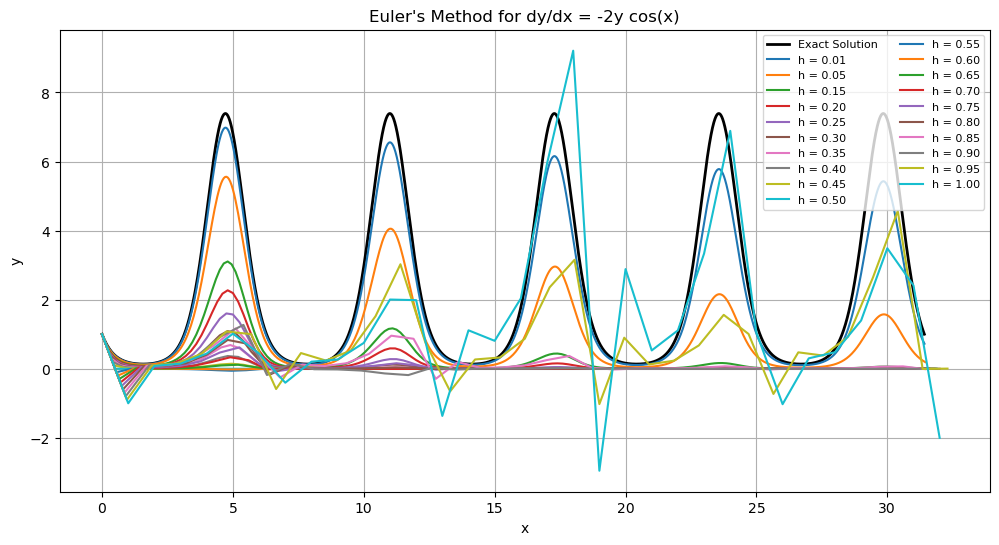

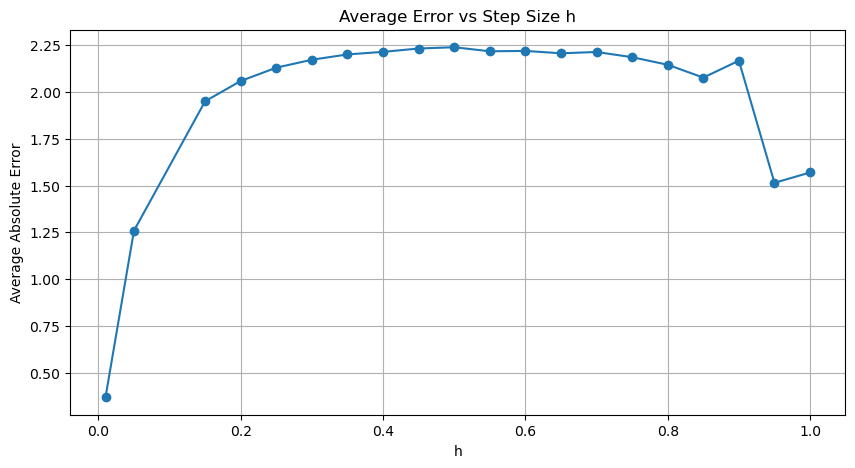

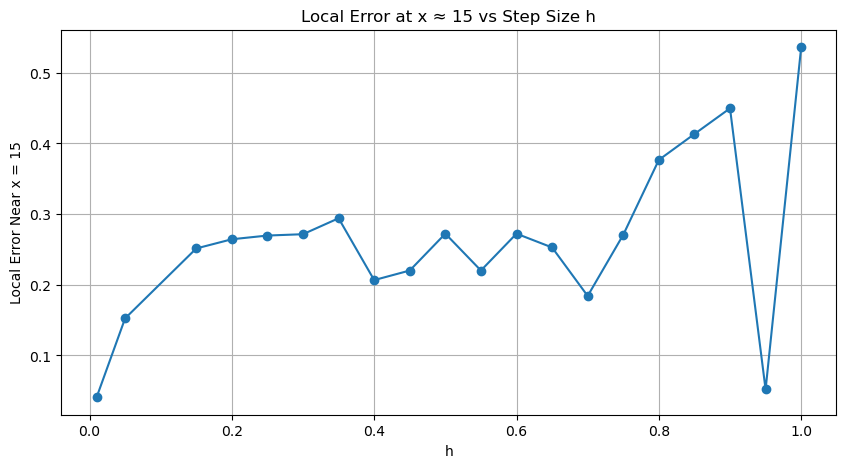


Average y-value for each run:
h = 0.01, average y = 1.910450
h = 0.05, average y = 1.017291
h = 0.15, average y = 0.319016
h = 0.20, average y = 0.203286
h = 0.25, average y = 0.135263
h = 0.30, average y = 0.090738
h = 0.35, average y = 0.060342
h = 0.40, average y = 0.039020
h = 0.45, average y = 0.024619
h = 0.50, average y = 0.015625
h = 0.55, average y = 0.011765
h = 0.60, average y = 0.013616
h = 0.65, average y = 0.021267
h = 0.70, average y = 0.033042
h = 0.75, average y = 0.058823
h = 0.80, average y = 0.066797
h = 0.85, average y = 0.167741
h = 0.90, average y = 0.071732
h = 0.95, average y = 0.767397
h = 1.00, average y = 1.289649

Comparison of y near x ≈ 15 for each run:
h = 0.01, x ≈ 15.000000, Euler y = 0.231440, Exact y = 0.272375, Local error = 0.040935
h = 0.05, x ≈ 15.000000, Euler y = 0.119869, Exact y = 0.272375, Local error = 0.152506
h = 0.15, x ≈ 15.000000, Euler y = 0.020921, Exact y = 0.272375, Local error = 0.251454
h = 0.20, x ≈ 15.000000, Euler y = 0.00790

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Homework 7 - Euler's Method
# ODE: dy/dx = -2y*cos(x), y(0) = 1
# Interval: x in [0, 10pi]

# differential equation
def f(x, y):
    return -2 * y * np.cos(x)

# exact solution
def y_exact(x):
    return np.exp(-2 * np.sin(x))

# Euler's method
def euler_method(h, x0, x_end, y0):
    x_values = np.arange(x0, x_end + h, h)
    y_values = np.zeros(len(x_values))
    y_values[0] = y0

    for i in range(len(x_values) - 1):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    return x_values, y_values

# parameters
x0 = 0
x_end = 10 * np.pi
y0 = 1

# step sizes from the prompt
h_values = [0.01, 0.05] + list(np.arange(0.15, 1.05, 0.05))

# store results
avg_y_values = []
avg_errors = []
local_errors = []
y_at_15_values = []

# Plot 1: Euler solutions for each h
plt.figure(figsize=(12, 6))

x_exact_plot = np.linspace(x0, x_end, 5000)
plt.plot(x_exact_plot, y_exact(x_exact_plot), 'k', linewidth=2, label='Exact Solution')

for h in h_values:
    x_vals, y_vals = euler_method(h, x0, x_end, y0)

    # exact values at the same x points
    y_true = y_exact(x_vals)

    # average y value for this run
    avg_y = np.mean(y_vals)
    avg_y_values.append(avg_y)

    # average absolute error over the whole run
    avg_error = np.mean(np.abs(y_vals - y_true))
    avg_errors.append(avg_error)

    # value near x = 15
    idx_15 = np.argmin(np.abs(x_vals - 15))
    x_near_15 = x_vals[idx_15]
    y_near_15 = y_vals[idx_15]
    y_true_15 = y_true[idx_15]

    y_at_15_values.append((h, x_near_15, y_near_15, y_true_15))

    # local error near x = 15
    local_error = abs(y_near_15 - y_true_15)
    local_errors.append(local_error)

    # plot this Euler run
    plt.plot(x_vals, y_vals, label=f'h = {h:.2f}')

plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler's Method for dy/dx = -2y cos(x)")
plt.legend(ncol=2, fontsize=8)
plt.grid(True)
plt.show()

# Plot 2: Average error vs h
plt.figure(figsize=(10, 5))
plt.plot(h_values, avg_errors, marker='o')
plt.xlabel('h')
plt.ylabel('Average Absolute Error')
plt.title('Average Error vs Step Size h')
plt.grid(True)
plt.show()

# Plot 3: Local error near x = 15 vs h
plt.figure(figsize=(10, 5))
plt.plot(h_values, local_errors, marker='o')
plt.xlabel('h')
plt.ylabel('Local Error Near x = 15')
plt.title('Local Error at x ≈ 15 vs Step Size h')
plt.grid(True)
plt.show()

# Print requested comparisons
print("\nAverage y-value for each run:")
for h, avg_y in zip(h_values, avg_y_values):
    print(f"h = {h:.2f}, average y = {avg_y:.6f}")

print("\nComparison of y near x ≈ 15 for each run:")
for h, x15, y_num, y_true_15 in y_at_15_values:
    print(f"h = {h:.2f}, x ≈ {x15:.6f}, Euler y = {y_num:.6f}, Exact y = {y_true_15:.6f}, Local error = {abs(y_num - y_true_15):.6f}")